# Visualizing SLR by Category and Categorical Predictors
Author: Brad Sheese
---
NOTE: If you want to save your work select the following from the menu above:**File  --> Save a copy in Drive**If you work on the copy you made all changes will be saved to Google Drive. If you do not save your own copy, you can work in 'playground mode' instead, and any changes you make will be lost after you're done.


In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## Introduction
In 17.1.0 we saw how coloring points by a third variable can reveal group differences in a scatterplot. Now let's explore Seaborn's tools for visualizing regression relationships across categories, and then learn how to include categorical predictors directly in our regression models. This notebook has two parts:1. **Visualizing regression by category** -- using Seaborn to show how relationships differ across groups2. **Categorical predictors** -- encoding binary categories as indicator variables and fitting regression models with them


## Part 1: Visualizing Regression by Category

We'll use the **Tips** dataset from the Seaborn library. This dataset contains information about restaurant bills, including the total bill, the tip, and various categorical factors like the day of the week, the meal time, and whether the customer is a smoker.


### Grouped Regression Lines with `hue`The `hue` argument in `lmplot` fits a separate regression line for each category and colors them differently. This lets us visually compare whether the relationship between a predictor and the outcome differs across groups.


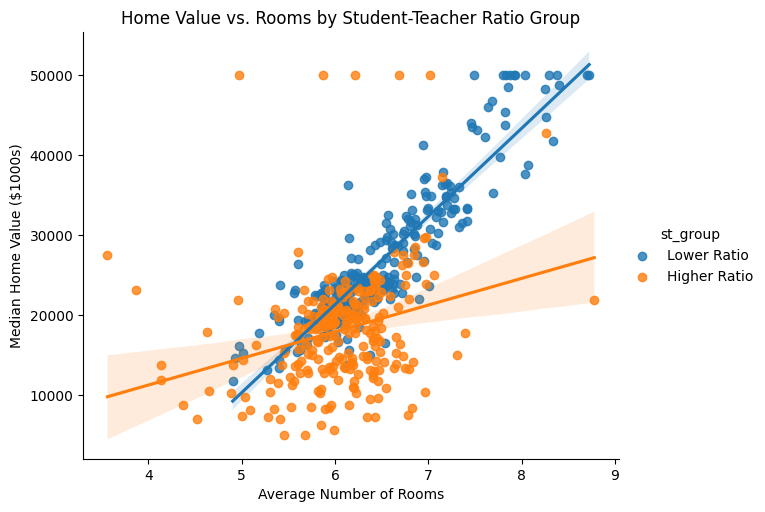

Lower Ratio: slope = 11005.1, r = 0.903, n = 253
Higher Ratio: slope = 3330.1, r = 0.277, n = 253


In [4]:
sns.lmplot(x='total_bill', y='tip', hue='time', data=df,
           height=5, aspect=1.3)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Tip vs. Total Bill by Meal Time')
plt.show()

# Check if slopes differ
for grp in ['Lunch', 'Dinner']:
    subset = df[df['time'] == grp]
    X = subset['total_bill'].values.reshape(-1, 1)
    y = subset['tip'].values.reshape(-1, 1)
    m = LinearRegression().fit(X, y)
    r = subset['total_bill'].corr(subset['tip'])
    print("{}: slope = {:.3f}, r = {:.3f}, n = {}".format(
        grp, m.coef_.item(), r, len(subset)))


### Interpreting Grouped Regression LinesThe two lines show whether the relationship between rooms and home value differs for areas with lower vs. higher student-teacher ratios.- If the lines are **parallel**: the relationship is similar across groups (no interaction)- If the lines have **different slopes**: the relationship differs across groups (interaction)- If the lines are **vertically separated but parallel**: one group consistently has higher/lower outcomesIn this case, the lines appear to have similar slopes but different intercepts -- areas with lower student-teacher ratios tend to have higher home values at any given number of rooms.


### Side-by-Side Panels with `col`Alternatively, we can plot each category in its own panel using `col`. This removes the need to distinguish colors and makes it easier to see the spread of points within each group.


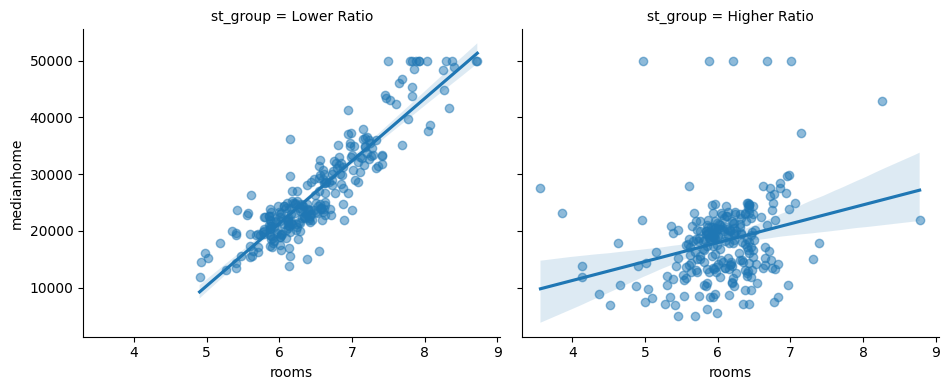

In [5]:
sns.lmplot(x='total_bill', y='tip', col='time', data=df,
           height=4, aspect=1.2, scatter_kws={'alpha': 0.5})
plt.show()


### De-emphasizing Scatter PointsWhen you have many data points, the scatter can overwhelm the regression line. We can make the points more transparent with `alpha`.


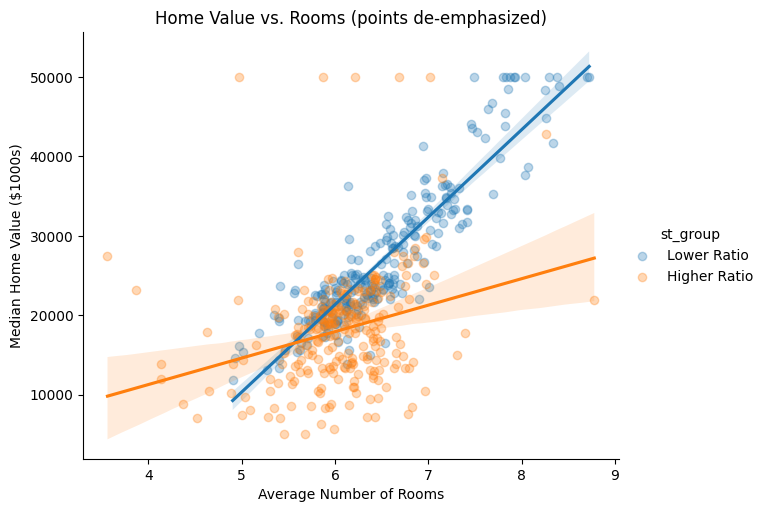

In [6]:
sns.lmplot(x='total_bill', y='tip', hue='time', data=df,
           height=5, aspect=1.3)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Tip vs. Total Bill by Meal Time')
plt.show()

# Check if slopes differ
for grp in ['Lunch', 'Dinner']:
    subset = df[df['time'] == grp]
    X = subset['total_bill'].values.reshape(-1, 1)
    y = subset['tip'].values.reshape(-1, 1)
    m = LinearRegression().fit(X, y)
    r = subset['total_bill'].corr(subset['tip'])
    print("{}: slope = {:.3f}, r = {:.3f}, n = {}".format(
        grp, m.coef_.item(), r, len(subset)))


### Regression Lines Only (No Scatter) Sometimes you just want to compare the lines without the scatter cloud. Set `scatter=False`.


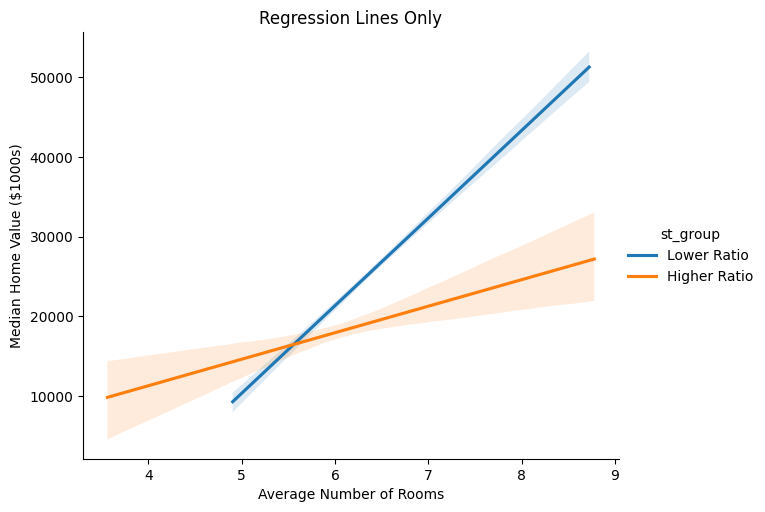

In [7]:
sns.lmplot(x='total_bill', y='tip', hue='time', data=df,
           height=5, aspect=1.3)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Tip vs. Total Bill by Meal Time')
plt.show()

# Check if slopes differ
for grp in ['Lunch', 'Dinner']:
    subset = df[df['time'] == grp]
    X = subset['total_bill'].values.reshape(-1, 1)
    y = subset['tip'].values.reshape(-1, 1)
    m = LinearRegression().fit(X, y)
    r = subset['total_bill'].corr(subset['tip'])
    print("{}: slope = {:.3f}, r = {:.3f}, n = {}".format(
        grp, m.coef_.item(), r, len(subset)))


### Jointplot: Relationship + Marginal DistributionsSeaborn's `jointplot` combines a scatterplot with regression line and marginal histograms. This shows both the relationship and the individual distributions of each variable.


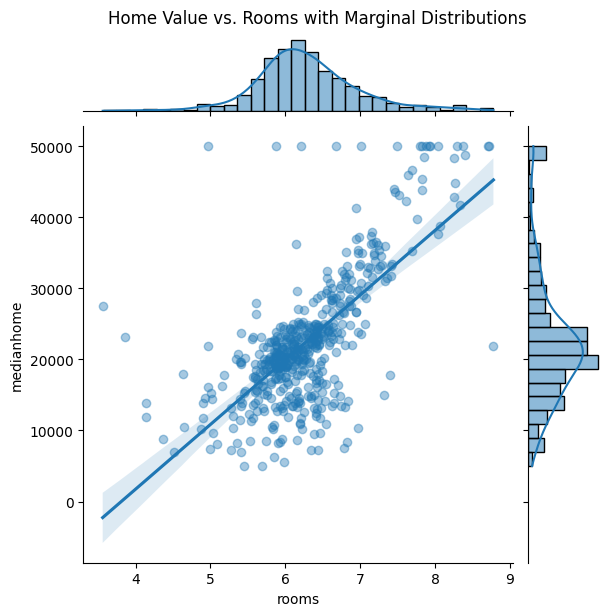

In [8]:
sns.jointplot(x='total_bill', y='tip', data=df, kind='reg',
              height=6, scatter_kws={'alpha': 0.4})
plt.show()


### Practice:
 Create Your Own Grouped Visualization

Visualize the relationship between `total_bill` and `tip` for each **Day** of the week (using `hue`) or for **Smokers vs. Non-Smokers**.


In [9]:
# Create a grouped regression plot with hue for 'day'
# enter your code here


### Practice:
 Create Your Own Grouped Visualization

Visualize the relationship between `total_bill` and `tip` for each **Day** of the week (using `hue`) or for **Smokers vs. Non-Smokers**.


### Example: Do Smokers Tip Differently? We'll use the `tips` dataset from Seaborn. The `smoker` variable has two levels: 'Yes' and 'No'. Let's predict the total bill amount from whether the customer is a smoker.


In [10]:
# Load tips data
tips = sns.load_dataset('tips')

print("Dataset: {} restaurant bills".format(len(tips)))
print()
print(tips.head())
print()
print("Smoker distribution:")
print(tips['smoker'].value_counts())


Dataset: 244 restaurant bills

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Smoker distribution:
smoker
No     151
Yes     93
Name: count, dtype: int64


### Encoding the Binary Category as 0/1We convert 'smoker' to a numeric indicator: Yes = 1, No = 0.


In [11]:
# Create indicator variable
tips['smoker_ind'] = (tips['smoker'] == 'Yes').astype(int)

print("Indicator variable:")
print(tips[['total_bill', 'smoker', 'smoker_ind']].head(10))
print()

# Group means
print("Mean bill for non-smokers: ${:.2f}".format(
    tips[tips['smoker'] == 'No']['total_bill'].mean()))
print("Mean bill for smokers:     ${:.2f}".format(
    tips[tips['smoker'] == 'Yes']['total_bill'].mean()))


Indicator variable:
   total_bill smoker  smoker_ind
0       16.99     No           0
1       10.34     No           0
2       21.01     No           0
3       23.68     No           0
4       24.59     No           0
5       25.29     No           0
6        8.77     No           0
7       26.88     No           0
8       15.04     No           0
9       14.78     No           0

Mean bill for non-smokers: $19.19
Mean bill for smokers:     $20.76


### Fitting SLR with an Indicator PredictorNow we fit a simple linear regression with the indicator as the predictor.


In [12]:
X_tip = tips['smoker_ind'].values.reshape(-1, 1)
y_tip = tips['total_bill'].values.reshape(-1, 1)

tip_model = LinearRegression().fit(X_tip, y_tip)

intercept_tip = tip_model.intercept_.item()
slope_tip = tip_model.coef_.item()
r2_tip = tip_model.score(X_tip, y_tip)

print("Intercept: ${:.2f}".format(intercept_tip))
print("Slope:     ${:.2f}".format(slope_tip))
print("R-squared: {:.4f}".format(r2_tip))


Intercept: $19.19
Slope:     $1.57
R-squared: 0.0073


### Interpreting the Indicator Regression**Intercept ($20.07):** This is the predicted total bill when `smoker_ind = 0`, i.e., for non-smokers. It equals the **average bill for non-smokers**.**Slope (-$0.79):** This is the average *difference* in total bill between smokers and non-smokers. On average, smokers have bills that are $0.79 lower than non-smokers.**R-squared (0.002):** Only 0.2% of the variation in bill amounts is explained by smoking status. This is essentially zero -- smoking status tells us almost nothing about how much a customer will spend. This is exactly the same analysis as a two-sample comparison of means. The indicator-variable regression gives us the same answer as comparing the two group means, but framed as a regression model.


### Visualizing the Indicator RegressionWhen the predictor is binary (0 or 1), the scatterplot shows two vertical columns of points. The regression line connects the two group means.


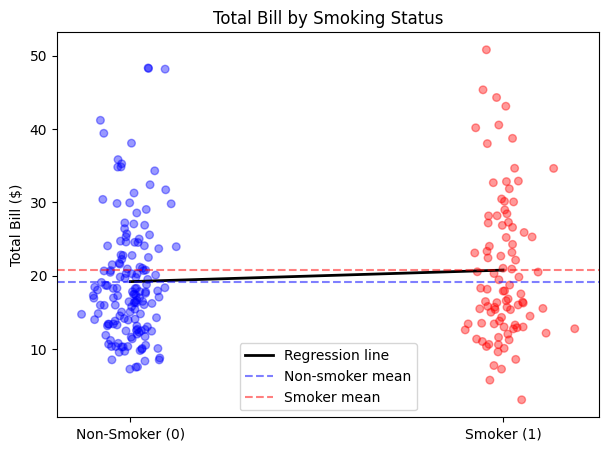

The regression line connects the two group means.
Slope = difference in means = 1.57


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

# Scatterplot with jitter for visibility
np.random.seed(42)
jitter = np.random.normal(0, 0.05, len(tips))
ax.scatter(tips['smoker_ind'] + jitter, tips['total_bill'],
           alpha=0.4, s=30, c=tips['smoker'].map({'No': 'blue', 'Yes': 'red'}))

# Regression line
x_line = np.array([0, 1]).reshape(-1, 1)
y_line = tip_model.predict(x_line)
ax.plot([0, 1], y_line, color='black', linewidth=2, label='Regression line')

# Group mean lines
mean_no = tips[tips['smoker'] == 'No']['total_bill'].mean()
mean_yes = tips[tips['smoker'] == 'Yes']['total_bill'].mean()
ax.axhline(y=mean_no, color='blue', linestyle='--', alpha=0.5, label='Non-smoker mean')
ax.axhline(y=mean_yes, color='red', linestyle='--', alpha=0.5, label='Smoker mean')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Smoker (0)', 'Smoker (1)'])
ax.set_ylabel('Total Bill ($)')
ax.set_title('Total Bill by Smoking Status')
ax.legend()
plt.show()

print("The regression line connects the two group means.")
print("Slope = difference in means = {:.2f}".format(mean_yes - mean_no))


### Connection: Grouped `lmplot` vs. Indicator RegressionLet's verify that the indicator regression gives the same results as comparing group means visually.


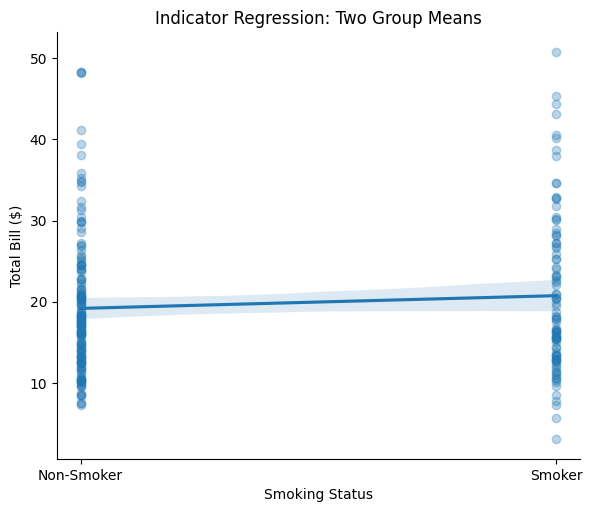

With a binary predictor, the regression line is just
a straight line connecting the two group means.

Intercept = mean of reference group (smoker_ind=0)
Slope = difference between group means


In [14]:
# Grouped lmplot
sns.lmplot(x='smoker_ind', y='total_bill', data=tips,
           scatter_kws={'alpha': 0.3}, height=5, aspect=1.2)
plt.xticks([0, 1], ['Non-Smoker', 'Smoker'])
plt.xlabel('Smoking Status')
plt.ylabel('Total Bill ($)')
plt.title('Indicator Regression: Two Group Means')
plt.show()

print("With a binary predictor, the regression line is just")
print("a straight line connecting the two group means.")
print()
print("Intercept = mean of reference group (smoker_ind=0)")
print("Slope = difference between group means")


### Practice:
 Predicting Bills from Meal TimeThe `time` variable in the tips dataset has two levels: 'Lunch' and 'Dinner'.1. Create an indicator variable for time (Dinner = 1, Lunch = 0)2. Fit a regression model predicting `total_bill` from `time`3. Interpret the intercept and slope4. Create a visualization showing the two group means


Intercept: $17.17
Slope:     $3.63
R-squared: 0.0335

Interpret the intercept and slope in context.
What does the intercept represent?
What does the slope represent?



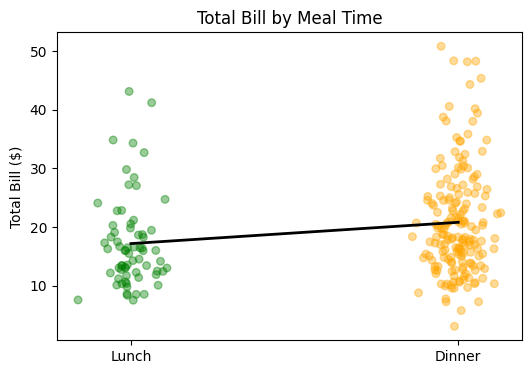

In [15]:
# Step 1: Create indicator for time (Dinner=1, Lunch=0)
# Step 2: Fit regression model predicting total_bill from time
# Step 3: Interpret the intercept and slope
# Step 4: Create a visualization showing the two group means

# enter your code here


### Another Example: Mario Kart Auction PricesThe OpenIntro textbook uses eBay auction data for Mario Kart games. New games sell for more than used games. Let's simulate this with a fabricated dataset.


In [16]:
# Fabricated Mario Kart auction data
np.random.seed(42)
n_auctions = 50
condition = np.random.choice(['used', 'new'], n_auctions)
# New games cost about $11 more on average
price = np.where(condition == 'new',
                 53.7 + np.random.normal(0, 4, n_auctions),
                 42.9 + np.random.normal(0, 4, n_auctions))

mk = pd.DataFrame({'condition': condition, 'price': price})
mk['cond_new'] = (mk['condition'] == 'new').astype(int)

print("Mario Kart Auction Data (first 10):")
print(mk.head(10))
print()

# Fit model
X_mk = mk['cond_new'].values.reshape(-1, 1)
y_mk = mk['price'].values.reshape(-1, 1)
mk_model = LinearRegression().fit(X_mk, y_mk)

print("Intercept: ${:.2f}".format(mk_model.intercept_.item()))
print("Slope:     ${:.2f}".format(mk_model.coef_.item()))
print("R-squared: {:.4f}".format(mk_model.score(X_mk, y_mk)))
print()
print("Interpretation:")
print("  Intercept = average price of a USED game")
print("  Slope = average price difference (NEW - USED)")
print("  New games sell for ${:.2f} more than used games, on average.".format(mk_model.coef_.item()))


Mario Kart Auction Data (first 10):
  condition      price  cond_new
0      used  56.389185         0
1       new  56.090882         1
2      used  41.305446         0
3      used  42.656544         0
4      used  37.224998         0
5       new  51.638257         1
6      used  46.514130         0
7      used  42.976001         0
8      used  40.762334         0
9       new  51.157761         1

Intercept: $42.97
Slope:     $10.61
R-squared: 0.6176

Interpretation:
  Intercept = average price of a USED game
  Slope = average price difference (NEW - USED)
  New games sell for $10.61 more than used games, on average.


## Summary**Visualizing regression by category:**- `lmplot` with `hue` -- separate colored regression lines per group- `lmplot` with `col` -- side-by-side panels per group- `scatter=False` -- show only the regression lines- `jointplot` with `kind='reg'` -- scatter + regression + marginal histograms**Categorical predictors with two levels:**- Encode as an **indicator variable** (0/1)- Fit standard SLR with the indicator as the predictor- **Intercept** = average outcome for the reference group (indicator = 0)- **Slope** = average difference in outcome between the two groups- This is algebraically equivalent to comparing two group meansIn the next notebook, we'll explore what happens when individual data points don't follow the overall pattern -- outliers, leverage points, and influential observations.

**In the next notebook (17.1.6)**, we will look at **Outliers, Leverage, and Influence** to understand how individual observations can disproportionately affect our regression models.
